# LIF Neuron model definition & recording.
In this notebook, or goal is to demonstrate a commonly-used neuron model in Spiking Neural Networks (SNNs), the Leaky Integrate-and-Fire (LIF). We define a network with a single LIF neuron, and export it for generating a dataflow accelerator with. This notebook covers:

1. A brief description of the neuron model with further resources.
2. Generation of sample input datasets.
3. Defining the LIF neuron from three different simulators.
4. Plotting the behaviour of the various simulators across tthe dataset.
5. Exporting the files for dataflow accelerator generation.

# 1. The Leaky Integrate-and-Fire neuron model

<img src="img/neuron.png">

Figure 1, as found in [Neuronal Dynamics Book](https://neuronaldynamics.epfl.ch/online/Ch1.S3.html).

A neuron cell's membrane has an associated voltage $u$, that is excited or inhibited by currents received from the dendrites (synapses). The LIF describes the neuronal membrane as a capacitor in parallel with a resistor, powered by idle current $u_\text{rest}$. Figure 1 shows the cell membrane on top, and it's Equivalent Circuit Model (ECT) on the bottom. This gives us the following model on to describe the voltage $u$:
$$\tau\frac{du}{dt} = -[u(t)-u_\text{rest}] + RI(t)$$
where $u(t)$ is our membrane (capacitor) voltage at time t, $\tau = RC$ is the membrane time constant that controls the timing regime of the model, and $I(t)$ is the sum of the synaptic current at timestep $t$.

The above equation is responsible for the *integration* part of the model, we further need to define a *fire* mechanism. We need the condition that once $u(t)$ reaches a threshold voltage $\theta$, we reset the membrane voltage to a passive state and commit a spike to the axon. We do this with the *reset condition*
$$\lim_{\delta \to 0; \delta > 0} u(t^{(f)} + \delta) + u_r$$
where $\delta$ defines how soon after the firing time $t^{(f)}$ we reset to the reset voltage $u_r$. The firing time can be described by:
$$t^{(f)} = \{t | u(t) = \theta\}$$
where $\theta$ is the threshold voltage.

Further reading on the LIF can be found on [Wikipedia](https://en.wikipedia.org/wiki/Biological_neuron_model#Leaky_integrate-and-fire) or in the [Neuronal Dynamics book](https://neuronaldynamics.epfl.ch/online/Ch1.S3.html).
In the rest of this notebook, we will define a LIF model in 3 various simulators, record their changes across multiple inputs, and save them for further processing in the second hands-on part.




## Imports

In [1]:
from pathlib import Path
import numpy as np
import torch
import nir
import norse.torch as norse_torch
import sinabs
import sinabs.layers as sl
from sinabs.activation import SingleSpike, MembraneReset
import matplotlib.pyplot as plt

output_dir   = Path("./outputs")
norse_dir    = output_dir / "norse"
sinabs_dir   = output_dir / "sinabs"
for d in (output_dir, norse_dir, sinabs_dir):
    d.mkdir(parents=True, exist_ok=True)

torch.manual_seed(42)

# 2. Define Dataset

10 samples, each with a parametrisable spike rate.

In [2]:
def make_dataset(
    num_samples: int = 10,
    num_timesteps: int = 200,
    num_inputs: int = 1,
    current_range: tuple[float, float] = (2.0, 20.0),
    min_spikes: int = 5,
    max_spikes: int = 40,
    seed: int = 42,
) -> torch.Tensor:
    """Generate a dataset of shape (num_samples, num_timesteps, num_inputs).

    Each sample's input current amplitude is linearly spaced across current_range,
    so the dataset sweeps from sub-threshold to strongly spiking behaviour.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    amplitudes = np.linspace(current_range[0], current_range[1], num_samples)
    data = torch.zeros((num_samples, num_timesteps, num_inputs))
    for i, amp in enumerate(amplitudes):
        n = np.random.randint(min_spikes, max_spikes + 1)
        positions = np.random.choice(num_timesteps, size=n, replace=False)
        data[i, positions, 0] = float(amp)
    return data

dataset = make_dataset()
sample = dataset[len(dataset) // 2]  # mid-range amplitude
print(f"Dataset shape: {dataset.shape}  (samples, timesteps, inputs)")

Dataset shape: torch.Size([10, 200, 1])  (samples, timesteps, inputs)


# Shared neuron parameters

In [3]:
tau_mem_ms = 20.0   # membrane time constant [ms]
v_th       = 1.0    # spike threshold
v_reset    = 0.0    # reset potential after spike

## Plotting helper

In [4]:
def plot_neuron(v_mem, spikes=None, title="", filename=None):
    """
    Plot membrane voltage and optional spike raster for a single neuron.

    Args:
        v_mem:    1-D array-like of membrane voltages
        spikes:   1-D array-like of spike values (binary), or None for LI
        title:    plot title
        filename: save path, or None to show inline
    """
    v = np.asarray(v_mem).squeeze()
    time = np.arange(len(v))

    has_spikes = spikes is not None
    nrows = 2 if has_spikes else 1
    _, axes = plt.subplots(nrows, 1, figsize=(14, 3 * nrows), sharex=True)
    if nrows == 1:
        axes = [axes]

    axes[0].plot(time, v, linewidth=0.8, color="steelblue")
    axes[0].set_ylabel("$v_{mem}$")
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)

    if has_spikes:
        s = np.asarray(spikes).squeeze()
        spike_times = np.where(s > 0.5)[0]
        axes[1].vlines(spike_times, 0, 1, color="crimson", linewidth=0.8)
        axes[1].set_ylabel("spikes")
        axes[1].set_ylim(-0.1, 1.4)
        axes[1].set_yticks([])
        axes[1].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Timestep")
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150)
    plt.show()

# LIF — Norse

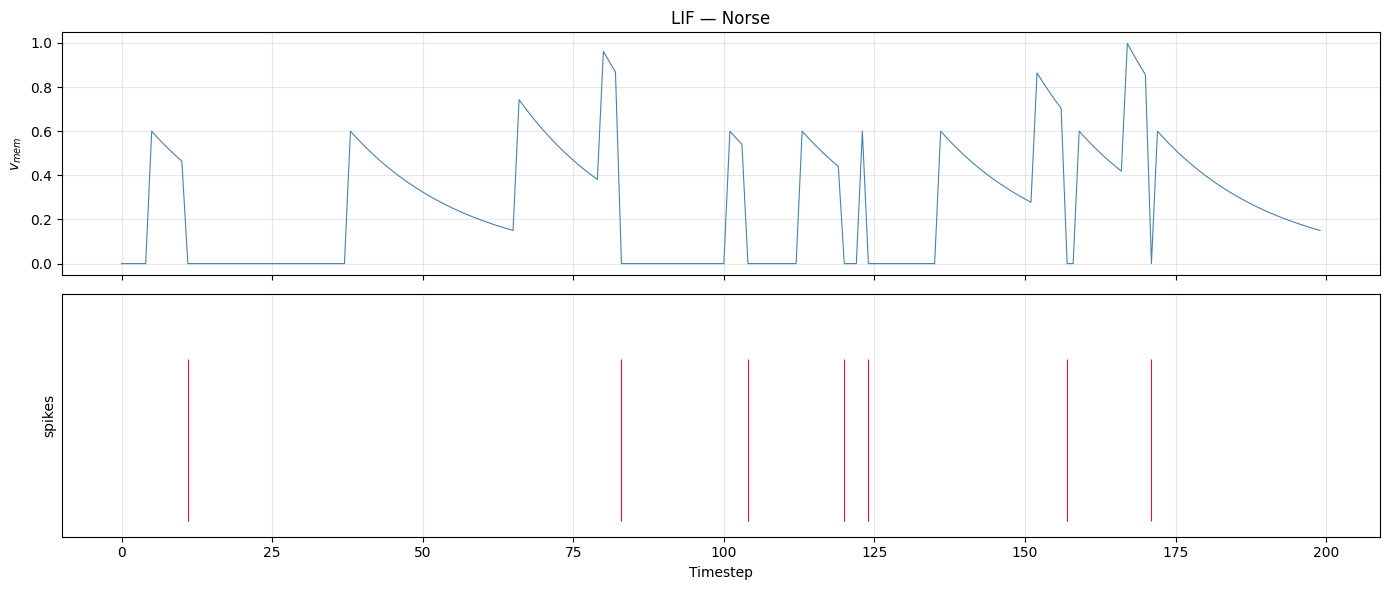

In [5]:
norse_lif = norse_torch.LIFBoxCell(
    p=norse_torch.LIFBoxParameters(
        tau_mem_inv=torch.tensor([1000.0 / tau_mem_ms]),
        v_th=torch.tensor([v_th]),
        v_reset=torch.tensor([v_reset]),
        v_leak=torch.tensor([0.0]),
    )
)

nir_lif_norse = norse_torch.to_nir(norse_lif, sample)
nir_lif_norse.nodes["norse"].tau = nir_lif_norse.nodes["norse"].tau * 1000 * 1000

norse_lif_state = norse_torch.LIFBoxFeedForwardState(v=torch.zeros(1))
v_mem_norse_lif, spikes_norse_lif = [], []
for t in sample:
    z, norse_lif_state = norse_lif(t, norse_lif_state)
    spikes_norse_lif.append(z.detach())
    v_mem_norse_lif.append(norse_lif_state.v.detach())

norse_lif_recordings = {
    "v_mem":  torch.stack(v_mem_norse_lif).numpy(),
    "spikes": torch.stack(spikes_norse_lif).numpy(),
}

plot_neuron(
    norse_lif_recordings["v_mem"],
    norse_lif_recordings["spikes"],
    title="LIF — Norse",
    filename=str(norse_dir / "lif.png"),
)

# LI — Norse

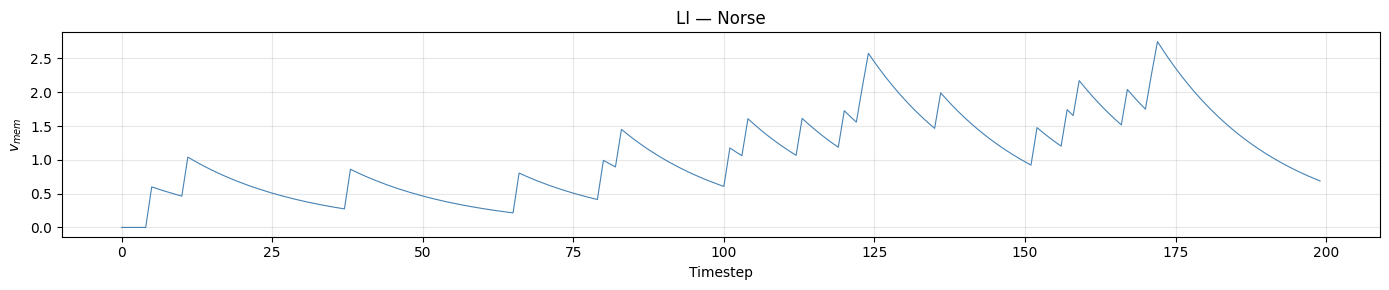

In [6]:
norse_li = norse_torch.LIBoxCell(
    p=norse_torch.LIBoxParameters(
        tau_mem_inv=torch.tensor([1000.0 / tau_mem_ms]),
        v_leak=torch.tensor([0.0]),
    )
)

nir_li_norse = norse_torch.to_nir(norse_li, sample)
nir_li_norse.nodes["norse"].tau = nir_li_norse.nodes["norse"].tau * 1000 * 1000  # dt=0.001 → dt=1

norse_li_state = norse_torch.LIBoxState(v=torch.zeros(1))
v_mem_norse_li = []
for t in sample:
    _, norse_li_state = norse_li(t, norse_li_state)
    v_mem_norse_li.append(norse_li_state.v.detach())

norse_li_recordings = {
    "v_mem": torch.stack(v_mem_norse_li).numpy(),
}

plot_neuron(
    norse_li_recordings["v_mem"],
    title="LI — Norse",
    filename=str(norse_dir / "li.png"),
)

# LIF — Sinabs

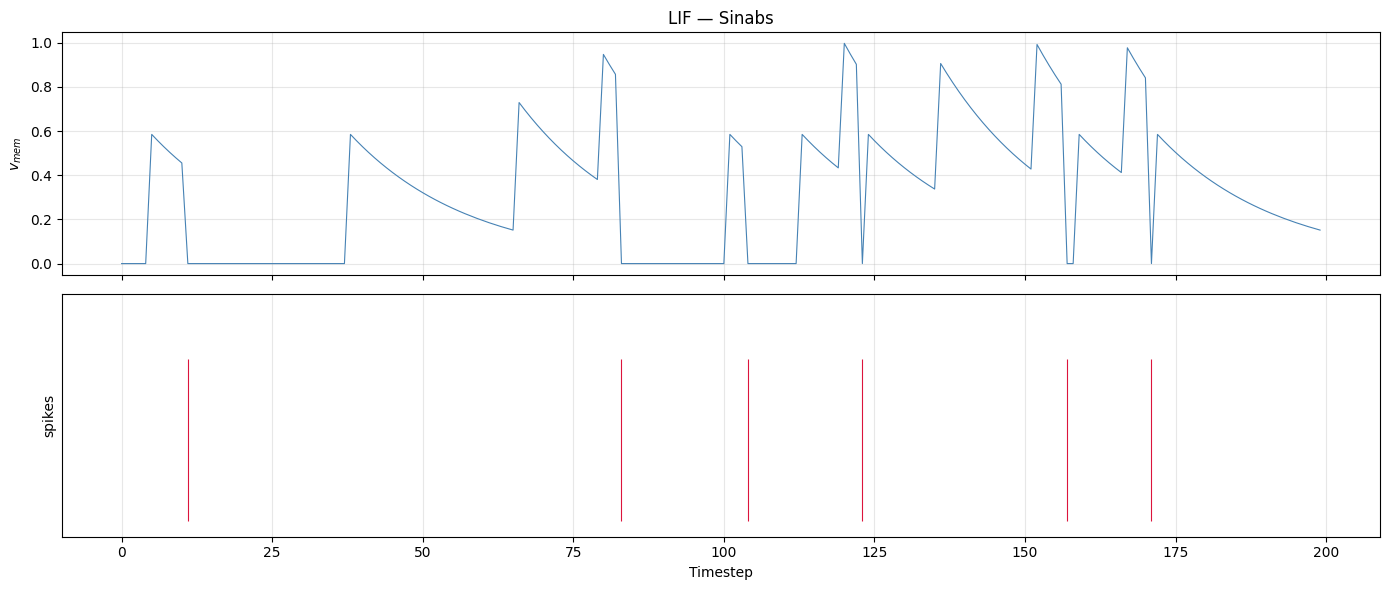

In [7]:
sinabs_lif = sl.LIF(
    tau_mem=tau_mem_ms,
    spike_threshold=v_th,
    spike_fn=SingleSpike,
    reset_fn=MembraneReset(reset_value=v_reset),
)

v_mem_sinabs_lif, spikes_sinabs_lif = [], []
sinabs_lif.reset_states()
for t in sample:
    x_t = t.unsqueeze(0).unsqueeze(0)
    out = sinabs_lif(x_t)
    spikes_sinabs_lif.append(out.squeeze(0).squeeze(0).detach())
    v_mem_sinabs_lif.append(sinabs_lif.v_mem.squeeze(0).detach())

nir_lif_sinabs = sinabs.to_nir(sinabs_lif, sample)

sinabs_lif_recordings = {
    "v_mem":  torch.stack(v_mem_sinabs_lif).numpy(),
    "spikes": torch.stack(spikes_sinabs_lif).numpy(),
}

plot_neuron(
    sinabs_lif_recordings["v_mem"],
    sinabs_lif_recordings["spikes"],
    title="LIF — Sinabs",
    filename=str(sinabs_dir / "lif.png"),
)

# LI — Sinabs

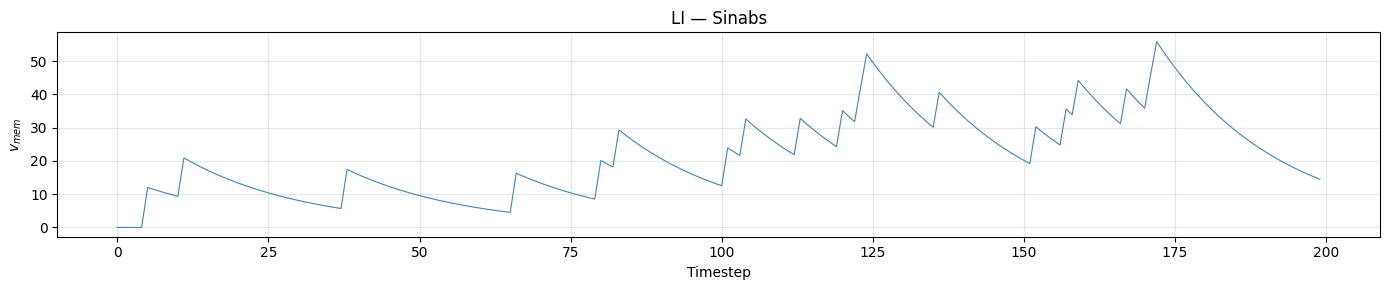

In [8]:
sinabs_li = sl.ExpLeak(tau_mem=tau_mem_ms)

v_mem_sinabs_li = []
sinabs_li.reset_states()
for t in sample:
    x_t = t.unsqueeze(0).unsqueeze(0)
    out = sinabs_li(x_t)
    v_mem_sinabs_li.append(out.squeeze(0).squeeze(0).detach())

nir_li_sinabs = sinabs.to_nir(sinabs_li, sample)

sinabs_li_recordings = {
    "v_mem": torch.stack(v_mem_sinabs_li).numpy(),
}

plot_neuron(
    sinabs_li_recordings["v_mem"],
    title="LI — Sinabs",
    filename=str(sinabs_dir / "li.png"),
)

# LIF — JAX (spyx)
TODO: Jens

In [9]:
# TODO: Jens — spyx / JAX LIF implementation
# Expected outputs:
#   nir_lif_jax : nir.NIRGraph
#   jax_lif_recordings = {"v_mem": np.ndarray, "spikes": np.ndarray}
#
# plot_neuron(jax_lif_recordings["v_mem"], jax_lif_recordings["spikes"],
#             title="LIF — JAX", filename=str(output_dir / "lif_jax.png"))

# LI — JAX (spyx)
TODO: Jens

In [10]:
# TODO: Jens — spyx / JAX LI implementation
# Expected outputs:
#   nir_li_jax : nir.NIRGraph
#   jax_li_recordings = {"v_mem": np.ndarray}
#
# plot_neuron(jax_li_recordings["v_mem"],
#             title="LI — JAX", filename=str(output_dir / "li_jax.png"))

# Combined comparison

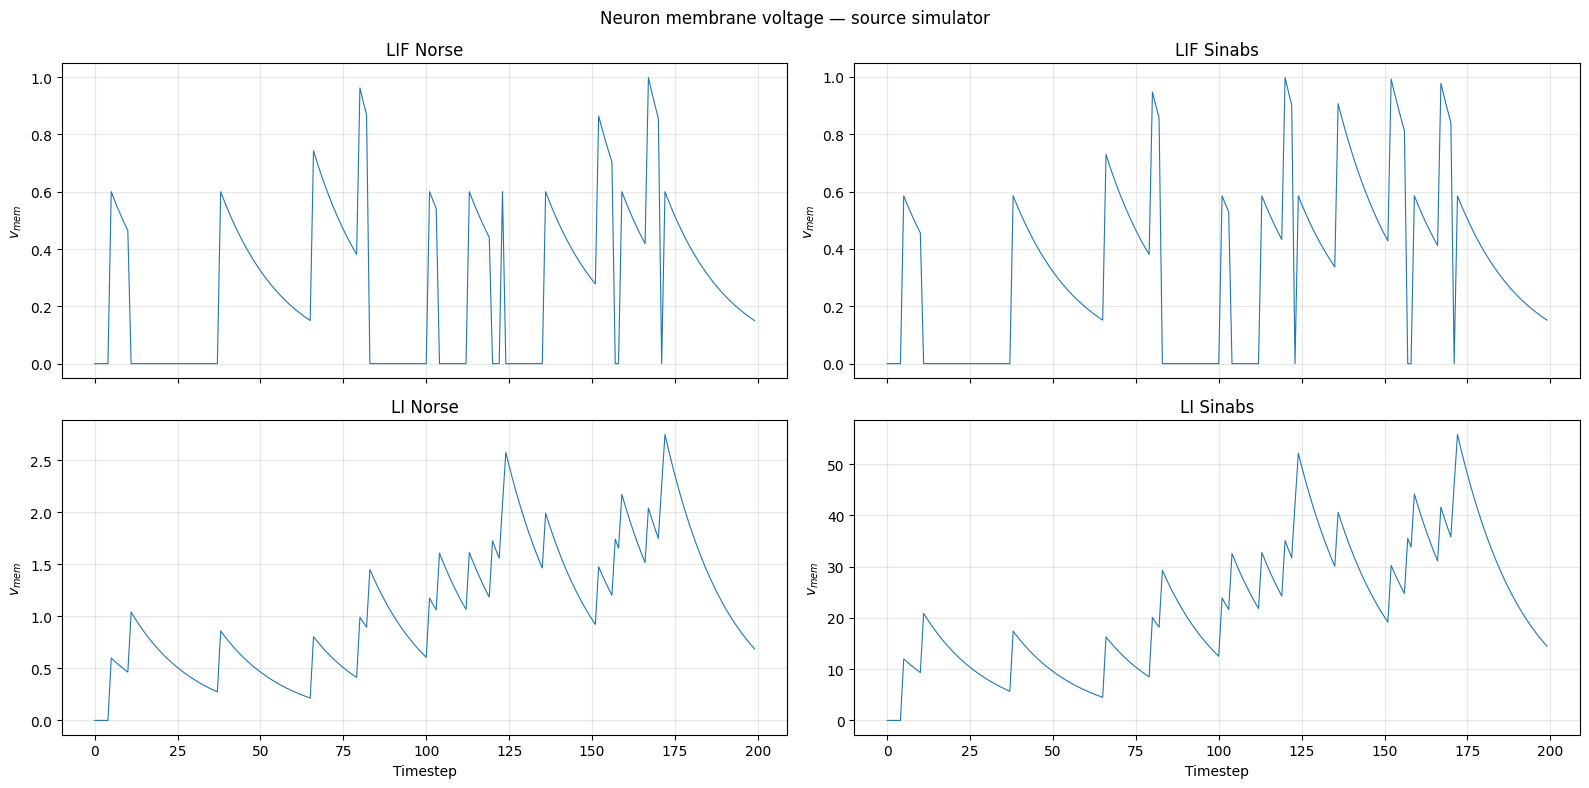

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
fig.suptitle("Neuron membrane voltage — source simulator")

pairs = [
    ("LIF Norse",  norse_lif_recordings["v_mem"]),
    ("LIF Sinabs", sinabs_lif_recordings["v_mem"]),
    ("LI Norse",   norse_li_recordings["v_mem"]),
    ("LI Sinabs",  sinabs_li_recordings["v_mem"]),
]

for ax, (title, v) in zip(axes.flat, pairs):
    ax.plot(np.asarray(v).squeeze(), linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("$v_{mem}$")
    ax.grid(True, alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("Timestep")

plt.tight_layout()
plt.savefig(str(output_dir / "comparison.png"), dpi=150)
plt.show()

# 5. Save NIR graphs and recordings

In [12]:
nir.write(str(norse_dir  / "lif.nir"), nir_lif_norse)
nir.write(str(norse_dir  / "li.nir"),  nir_li_norse)
nir.write(str(sinabs_dir / "lif.nir"), nir_lif_sinabs)
nir.write(str(sinabs_dir / "li.nir"),  nir_li_sinabs)
# TODO: Jens — add nir.write for JAX graphs

np.savez(str(norse_dir  / "lif_rec.npz"), **norse_lif_recordings)
np.savez(str(norse_dir  / "li_rec.npz"),  **norse_li_recordings)
np.savez(str(sinabs_dir / "lif_rec.npz"), **sinabs_lif_recordings)
np.savez(str(sinabs_dir / "li_rec.npz"),  **sinabs_li_recordings)
# TODO: Jens — add np.savez for JAX recordings

np.save(str(output_dir / "dataset.npy"), dataset.numpy())

print("Saved NIR graphs and recordings to", output_dir)

Saved NIR graphs and recordings to outputs
